In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5060 Ti


# Tiny Tao bridge: neural Discoverer on a thicker preregistered map

Question: can a population of tiny nets, given only `F` on a finite odd sample and a **bank** of candidate moduli, propose a residue partition that extracts to a **Level 5** universal descent certificate?

Map: `prospective_seven_and_three_mod_32`. Predictions were written to `tiny_tao_results/bridge_preregistration_seven_and_three_mod_32.json` **before** this run. Same frozen protocol as the 1/32 miss. Feature bank unchanged. `TOP_K_MODULI` unchanged. The Discoverer does **not** receive the hidden oracle proof or Collatz.

This is not a rerun of `prospective_seven_on_1_mod_32` with a larger shortlist.

Status: **exploratory / preregistered**. Do not run the oracle-comparison cell until discovery has finished.

## OSC launch

OnDemand **Jupyter** with a GPU. Suggested: 1 GPU, 4–8 CPU cores, 16 GB RAM, 1 hour. Open this notebook from `~/tao`.

The first code cell refuses to continue without CUDA (login nodes have no driver).

In [2]:
import os, sys, json, subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.home() / "tao"
if not (ROOT / "src" / "bridge").is_dir():
    ROOT = Path.cwd()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("cwd:", Path.cwd())
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Relaunch OSC Jupyter with a GPU request; "
        "do not run this notebook on a login node."
    )
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA runtime:", torch.version.cuda)
subprocess.run(
    ["nvidia-smi",
     "--query-gpu=name,utilization.gpu,memory.used,memory.total,power.draw",
     "--format=csv,noheader,nounits"],
    check=False,
)

cwd: /home/jmknapp/tao
Python: 3.12.3
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
CUDA runtime: 12.8


## Frozen protocol

Each net is a linear Lyapunov candidate

$$V(n)=\alpha\log n + \sum_M c^{(M)}_{n\bmod M}$$

on a **fixed** feature bank of moduli. The bank includes 16 as one of several $2^k$ options; nothing in the training loss is told that 16 is correct.

Training sample: odd $n\le N_{\mathrm{train}}$, labels $F(n)$ from the black box only.

In [3]:
MAP_NAME = "prospective_seven_and_three_mod_32"
N_TRAIN = 2000
N_FALSIFY = 20_000
POP = 1024
STEPS = 1500
LR = 3e-3
SEED = 20260909
TOP_K_MODULI = 8

from src.bridge.blackbox import get_blackbox
from src.bridge.discoverer import sweep_moduli
from src.bridge.neural_potential import FEATURE_MODULI, train_population
from src.bridge.verifier import verify

bb = get_blackbox(MAP_NAME)
ns = list(range(3, N_TRAIN + 1, 2))
fs = [bb.F_odd(n) for n in ns]
print(f"map={bb.name}  odd samples={len(ns)}  feature moduli={FEATURE_MODULI}")
print("black box only: T and F_odd. No oracle JSON, no residue table.")

map=prospective_seven_and_three_mod_32  odd samples=999  feature moduli=(2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 16, 24, 32)
black box only: T and F_odd. No oracle JSON, no residue table.


## Neural population

Loss: $\mathrm{ReLU}(V(F(n))-V(n)+0.1)$. Vectorized over the whole population on one GPU.

In [4]:
neural = train_population(
    ns, fs,
    pop=POP, steps=STEPS, lr=LR, seed=SEED,
    log_every=100, require_cuda=True,
)
print("device:", neural["device"])
print("final loss:", neural["loss"])
print("frac V(F)<V(n):", neural["frac_decrease"])
print("log n energy:", neural["logn_energy"])
print("top M by |W|^2:", neural["top_M"])
print("ranked moduli:")
for row in neural["ranked_moduli"]:
    print(f"  M={row['M']:>3}  energy={row['energy']:.5f}")

step     1  loss=0.2172  V(F)<V(n)=0.4989
step   100  loss=0.0010  V(F)<V(n)=0.9990
step   200  loss=0.0002  V(F)<V(n)=1.0000
step   300  loss=0.0001  V(F)<V(n)=1.0000
step   400  loss=0.0000  V(F)<V(n)=1.0000
step   500  loss=0.0000  V(F)<V(n)=1.0000
step   600  loss=0.0000  V(F)<V(n)=1.0000
step   700  loss=0.0000  V(F)<V(n)=1.0000
step   800  loss=0.0000  V(F)<V(n)=1.0000
step   900  loss=0.0000  V(F)<V(n)=1.0000
step  1000  loss=0.0000  V(F)<V(n)=1.0000
step  1100  loss=0.0000  V(F)<V(n)=1.0000
step  1200  loss=0.0000  V(F)<V(n)=1.0000
step  1300  loss=0.0000  V(F)<V(n)=1.0000
step  1400  loss=0.0000  V(F)<V(n)=1.0000
step  1500  loss=0.0000  V(F)<V(n)=1.0000
device: cuda
final loss: 1.1718476855548943e-07
frac V(F)<V(n): 1.0
log n energy: 0.0360872782766819
top M by |W|^2: 4
ranked moduli:
  M=  4  energy=0.00636
  M=  2  energy=0.00635
  M=  8  energy=0.00594
  M=  6  energy=0.00594
  M= 12  energy=0.00578
  M= 10  energy=0.00561
  M=  3  energy=0.00558
  M= 24  energy=0.00552
  

residue |W| profile at neural top M=4:
  r= 0  mean|W|=0.0645
  r= 2  mean|W|=0.0645
  r= 1  mean|W|=0.0643
  r= 3  mean|W|=0.0613


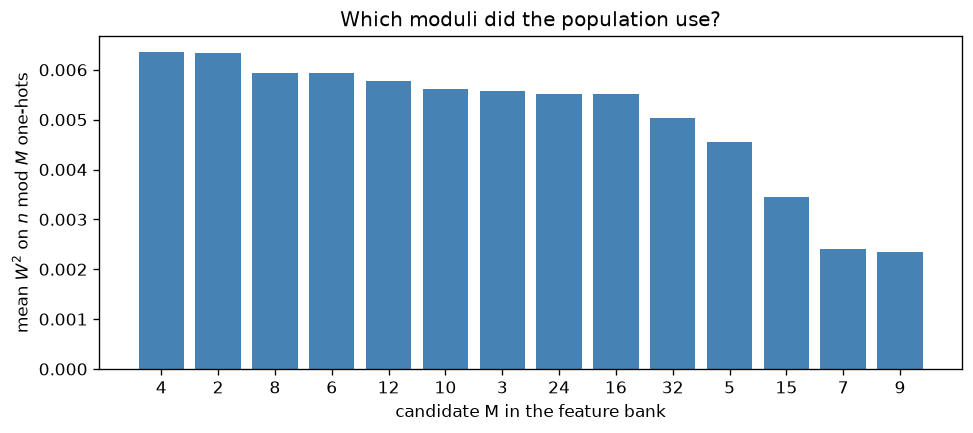

In [5]:
ranked = neural["ranked_moduli"]
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
ax.bar([str(r["M"]) for r in ranked], [r["energy"] for r in ranked], color="steelblue")
ax.set_xlabel("candidate M in the feature bank")
ax.set_ylabel(r"mean $W^2$ on $n\ \mathrm{mod}\ M$ one-hots")
ax.set_title("Which moduli did the population use?")
plt.show()

print(f"residue |W| profile at neural top M={neural['top_M']}:")
prof = neural["top_M_residue_profile"]
for r, val in sorted(prof.items(), key=lambda kv: -kv[1])[:12]:
    print(f"  r={str(r):>2}  mean|W|={val:.4f}")

## Extract certificate from the neural shortlist

Take the top `TOP_K_MODULI` by energy. Fit affine / odd-part lemmas on each, then keep the **smallest** complete covering that survives the exact Falsifier. Then attempt Level 5 (all-$q$ proof).

Energy ranking is a **hint**, not a certificate. Predictions for this map are locked in the preregistration JSON; do not change `TOP_K_MODULI` or the feature bank after seeing the ranking.

In [6]:
shortlist = tuple(row["M"] for row in neural["ranked_moduli"][:TOP_K_MODULI])
print("neural shortlist M =", shortlist)

ranked_certs = sweep_moduli(bb, n_max=N_TRAIN, moduli=shortlist)
attempts = []
chosen = None
ver = None
complete = [c for c in ranked_certs if not c.uncovered]
complete.sort(key=lambda c: (c.M, max((L.k for L in c.lemmas), default=99), len(c.lemmas)))
for cert in complete:
    v = verify(bb, cert, n_hi=N_FALSIFY)
    attempts.append({"M": cert.M, "passed": v["passed_falsifier"], "level": v["level"]})
    print(f"  try M={cert.M}  cover={cert.train_cover_frac:.3f}  {v['level']}  falsifier={v['passed_falsifier']}")
    if v["passed_falsifier"]:
        chosen, ver = cert, v
        break
if chosen is None:
    chosen = ranked_certs[0]
    ver = verify(bb, chosen, n_hi=N_FALSIFY)
    print("no shortlist covering survived the Falsifier")

print("\nchosen M=", chosen.M, "level=", ver["level"])
print("uncovered", list(chosen.uncovered))
print("universal", (ver.get("universal") or {}).get("proven"))
print("lemmas:")
for L in chosen.lemmas:
    if L.kind == "odd_part":
        print(f"  r={L.r:>3}  odd_part({L.a}n+{L.b})")
    else:
        print(f"  r={L.r:>3}  k={L.k}  F^k={L.A}q+{L.B}")

neural shortlist M = (4, 2, 8, 6, 12, 10, 3, 24)
no shortlist covering survived the Falsifier

chosen M= 8 level= LEVEL_1_survives_finite_testing
uncovered [1]
universal None
lemmas:
  r=  3  k=1  F^k=2q+1
  r=  5  k=1  F^k=4q+3
  r=  7  odd_part(1n+1)


## Success gate

`LEVEL_5_universal_descent` means the extracted lemmas are proved for every integer $q$.

Preregistered gate: the neural shortlist contains 32 **and** the extracted covering is Level 5 at $M=32$. If 32 is missing from the top 8, the gate is False — do not raise `TOP_K`.

In [7]:
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
run = Path("tiny_tao_results") / f"bridge_neural_{MAP_NAME}_{stamp}"
run.mkdir(parents=True, exist_ok=True)

def lemma_dict(L):
    return {"M": L.M, "r": L.r, "k": L.k, "A": L.A, "B": L.B,
            "kind": L.kind, "a": L.a, "b": L.b, "n_train": L.n_train}

level5 = ver["level"] == "LEVEL_5_universal_descent" and ver["passed_falsifier"]
gate = level5 and (32 in shortlist) and chosen.M == 32

payload = {
    "status": "exploratory",
    "map": MAP_NAME,
    "n_train": N_TRAIN,
    "n_falsify": N_FALSIFY,
    "seed": SEED,
    "pop": POP,
    "steps": STEPS,
    "feature_moduli": list(FEATURE_MODULI),
    "neural_shortlist": list(shortlist),
    "neural": {k: neural[k] for k in
               ("loss", "frac_decrease", "logn_energy", "top_M",
                "ranked_moduli", "top_M_residue_profile", "device", "pop", "steps")},
    "chosen_M": chosen.M,
    "lemmas": [lemma_dict(L) for L in chosen.lemmas],
    "uncovered": list(chosen.uncovered),
    "verifier": ver,
    "falsifier_attempts": attempts,
    "level5_gate": level5,
    "preregistered_gate": gate,
    "preregistration": "tiny_tao_results/bridge_preregistration_seven_and_three_mod_32.json",
}
(run / "summary.json").write_text(json.dumps(payload, indent=2))
print("wrote", run / "summary.json")
print("LEVEL_5 GATE:", level5)
print("shortlist contains 32:", 32 in shortlist)
print("extracted M:", chosen.M)
print("PREREGISTERED GATE:", gate)

wrote tiny_tao_results/bridge_neural_prospective_seven_and_three_mod_32_20260910_012529/summary.json
LEVEL_5 GATE: False
shortlist contains 32: False
extracted M: 8
PREREGISTERED GATE: False


## Compare to hidden oracle (run last)

Only after the success gate is recorded. This cell reads `tiny_tao_results/bridge_oracle_hidden/` and must not be used to change the Discoverer.

In [8]:
oracle_path = Path("tiny_tao_results/bridge_oracle_hidden") / f"{MAP_NAME}.json"
oracle = json.loads(oracle_path.read_text())
oc = oracle["certificate"]
o_lemmas = oc.get("lemmas") or []
o_k = sorted({L["k"] for L in o_lemmas})
print("oracle verified:", oc["verified"], "M:", oc["modulus"],
      "n_lemmas:", len(o_lemmas),
      "failures:", len(oc.get("failures") or []),
      "horizons:", o_k if len(o_lemmas) <= 64 else f"omitted (n={len(o_lemmas)})")
print("discovered M:", chosen.M, "level:", ver["level"],
      "kinds:", sorted({L.kind for L in chosen.lemmas}))
o_ok = bool(oc.get("verified"))
passed = bool(ver["passed_falsifier"]) and not chosen.uncovered
if passed and o_ok:
    relation = "smaller_covering" if chosen.M < oc["modulus"] else "covering_found"
elif (not passed) and (not o_ok):
    relation = "agreed_negative"
elif passed and not o_ok:
    relation = "discoverer_covered_oracle_did_not"
else:
    relation = "discoverer_failed_oracle_verified"
print("relation:", relation)

oracle verified: True M: 32 n_lemmas: 16 failures: 0 horizons: [1]
discovered M: 8 level: LEVEL_1_survives_finite_testing kinds: ['affine', 'odd_part']
relation: discoverer_failed_oracle_verified
